# 02 · ⚠️ La trampa: cómo "predecir" la lotería sin darse cuenta

> ## ⚠️ ESTE NOTEBOOK MUESTRA LO QUE **NO** SE DEBE HACER
> Los resultados "espectaculares" de las primeras secciones son **falsos**: salen de errores de validación, no de ninguna capacidad de predecir. El Baloto es aleatorio.
>
> **Experimento educativo. El Baloto es aleatorio; este modelo no predice resultados. Juega con responsabilidad.**

Dos errores clásicos que hacen parecer que un modelo funciona:

1. **Fuga de información + split aleatorio**: features que, sin querer, contienen el resultado que se quiere predecir, evaluadas mezclando al azar sorteos de todas las épocas.
2. **Sesgo de selección**: probar muchas estrategias y quedarse con la que mejor salió, en los mismos datos con los que se la mide.

Todo el código de la trampa está aislado en `baloto_ml/evaluation/trap.py` y **no se usa en el pipeline**.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from baloto_ml import viz
from baloto_ml.config import EXPECTED_HITS, JUEGOS, default_paths
from baloto_ml.data.store import read_draws
from baloto_ml.evaluation.trap import selection_bias_demo, trap_grid
from baloto_ml.models.base import GameData

viz.apply_style()
pd.set_option("display.precision", 3)
paths = default_paths()
FIG = paths.figures
data = {j: GameData.from_draws(read_draws(paths.processed_draws), j) for j in JUEGOS}


def ic(par):
    return f"[{par[0]:.3f}, {par[1]:.3f}]"

## 1. La receta tentadora

Es la que aparece en muchos tutoriales: para cada balota se calcula su frecuencia en los últimos 10, 30 y 100 sorteos con `rolling`, se separa un 25 % de los sorteos **al azar** para probar y se entrena una regresión logística por balota. El detalle que lo arruina es una sola línea:

```python
freq_10 = y.rolling(10).mean()            # ❌ la ventana TERMINA en el sorteo actual: incluye la respuesta
freq_10 = y.shift(1).rolling(10).mean()   # ✅ la ventana termina en el sorteo anterior
```

Sin el `.shift(1)`, la feature del sorteo *t* ya sabe si la balota salió en *t*.

In [2]:
filas = {j: trap_grid(data[j]) for j in JUEGOS}
tentadora = next(r for r in filas["baloto"] if r["features"].startswith("con fuga") and r["validacion"] == "split aleatorio")
display(Markdown(f"""Baloto, con la receta tentadora: **{tentadora['aciertos_top5']:.2f} aciertos por sorteo** jugando las 5 balotas más probables, contra {EXPECTED_HITS:.3f} por azar (IC95 % {ic(tentadora['aciertos_top5_ic95'])}), y una log-loss {100 * tentadora['skill_log_loss']:.1f} % mejor que el baseline. Si esto fuera real, sería el hallazgo del siglo. No lo es."""))

Baloto, con la receta tentadora: **1.37 aciertos por sorteo** jugando las 5 balotas más probables, contra 0.581 por azar (IC95 % [1.210, 1.522]), y una log-loss 9.6 % mejor que el baseline. Si esto fuera real, sería el hallazgo del siglo. No lo es.

## 2. Autopsia: ¿quién es el culpable?

Se separan los dos ingredientes: features **con fuga** o **correctas**, y validación con **split aleatorio** o **walk-forward** (entrenar solo con el pasado y predecir el futuro).

In [3]:
tabla = pd.DataFrame(
    [
        {
            "juego": j,
            "features": r["features"],
            "validación": r["validacion"],
            "sorteos de prueba": r["n_sorteos_prueba"],
            "aciertos top-5": r["aciertos_top5"],
            "IC95 aciertos": ic(r["aciertos_top5_ic95"]),
            "skill log-loss": r["skill_log_loss"],
        }
        for j in JUEGOS
        for r in filas[j]
    ]
).set_index(["juego", "features", "validación"])
tabla

sorteos de prueba  \
juego    features                             validación                           
baloto   con fuga (ventana incluye el sorteo) split aleatorio                134   
                                              walk-forward                   384   
         correctas (solo pasado)              split aleatorio                134   
                                              walk-forward                   384   
revancha con fuga (ventana incluye el sorteo) split aleatorio                134   
                                              walk-forward                   384   
         correctas (solo pasado)              split aleatorio                134   
                                              walk-forward                   384   

                                                               aciertos top-5  \
juego    features                             validación                        
baloto   con fuga (ventana incluye el sorteo) split aleatorio           1.366   
                                              walk-forward              1.508   
         correctas (solo pasado)              split aleatorio           0.582   
                                              walk-forward              0.576   
revancha con fuga (ventana incluye el sorteo) split aleatorio           1.478   
                                              walk-forward              1.479   
         correctas (solo pasado)              split aleatorio           0.560   
                                              walk-forward              0.581   

                                                                IC95 aciertos  \
juego    features                             validación                        
baloto   con fuga (ventana incluye el sorteo) split aleatorio  [1.210, 1.522]   
                                              walk-forward     [1.416, 1.600]   
         correctas (solo pasado)              split aleatorio  [0.470, 0.694]   
                                              walk-forward     [0.507, 0.644]   
revancha con fuga (ventana incluye el sorteo) split aleatorio  [1.325, 1.630]   
                                              walk-forward     [1.392, 1.566]   
         correctas (solo pasado)              split aleatorio  [0.449, 0.671]   
                                              walk-forward     [0.515, 0.647]   

                                                               skill log-loss  
juego    features                             validación                       
baloto   con fuga (ventana incluye el sorteo) split aleatorio           0.096  
                                              walk-forward              0.107  
         correctas (solo pasado)              split aleatorio          -0.014  
                                              walk-forward             -0.029  
revancha con fuga (ventana incluye el sorteo) split aleatorio           0.116  
                                              walk-forward              0.099  
         correctas (solo pasado)              split aleatorio          -0.013  
                                              walk-forward             -0.030

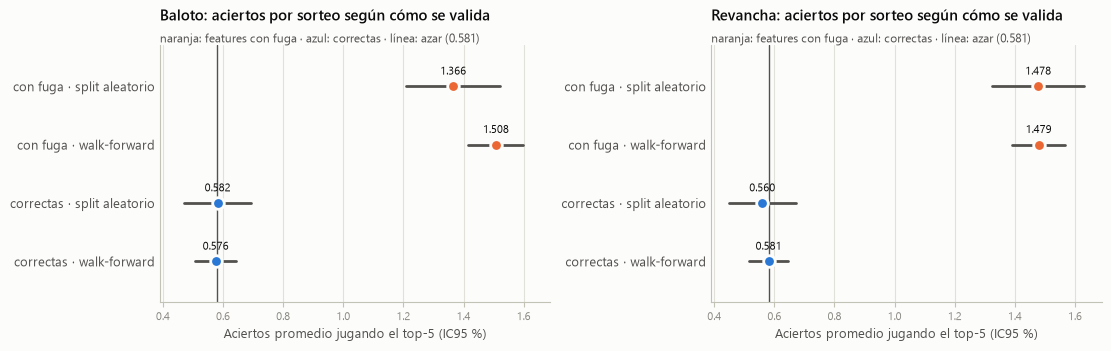

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharex=True, layout="constrained")
for ax, j in zip(axes, JUEGOS):
    rs = filas[j]
    etiquetas = [f"{'con fuga' if r['features'].startswith('con') else 'correctas'} · {r['validacion']}" for r in rs]
    viz.interval_dots(
        ax,
        etiquetas,
        [r["aciertos_top5"] for r in rs],
        [r["aciertos_top5_ic95"] for r in rs],
        EXPECTED_HITS,
        None,
        f"{j.capitalize()}: aciertos por sorteo según cómo se valida",
        "Aciertos promedio jugando el top-5 (IC95 %)",
        colors=[viz.ORANGE if r["features"].startswith("con") else viz.BLUE for r in rs],
        note="naranja: features con fuga · azul: correctas · línea: azar (0.581)",
    )
viz.save(fig, FIG / "trampa_fuga.png")
plt.show()

**Lectura.** El culpable principal aquí es la **fuga en las features**: con ella hasta el walk-forward "funciona", y sin ella ninguna validación encuentra nada. En una lotería el split aleatorio por sí solo no fabrica señal, porque los sorteos son independientes entre sí.

Entonces, ¿por qué el split aleatorio sigue prohibido en este proyecto?

- **No es así como se usará el modelo.** En producción siempre se predice el futuro con el pasado; validar de otra forma mide otra cosa.
- **En casi cualquier serie real sí filtra información.** Ventas, clima o precios tienen estructura temporal: con un split aleatorio el modelo aprende de los vecinos del futuro del sorteo que "predice". Que aquí no pase es una propiedad de la lotería, no del método.
- **Mezcla épocas.** Los sorteos de lunes existen solo desde junio de 2025; con un split aleatorio, un modelo "predice" sorteos de 2023 habiendo aprendido de lunes de 2026.
- **Esconde errores como la fuga.** Un protocolo que imita la producción (walk-forward + registro en vivo) obliga a calcular cada feature solo con lo que se sabía antes del sorteo.

¿Cómo se detecta una fuga? Con **tests** (este repo verifica que las features de cada sorteo se pueden calcular sin conocer ese sorteo, `tests/test_features.py`) y con el **registro en vivo**: una feature que usa el resultado no se puede calcular antes de que ocurra el sorteo.

## 3. Segunda trampa: probar muchas estrategias y quedarse con la mejor

80 estrategias de números "calientes" y "fríos": jugar las 5 balotas más (o menos) frecuentes en los últimos *w* sorteos, con *w* de 5 a 200. Se elige la mejor en la primera mitad del periodo de prueba (**A**) y se la vuelve a medir en la segunda mitad (**B**), que no participó en la elección.

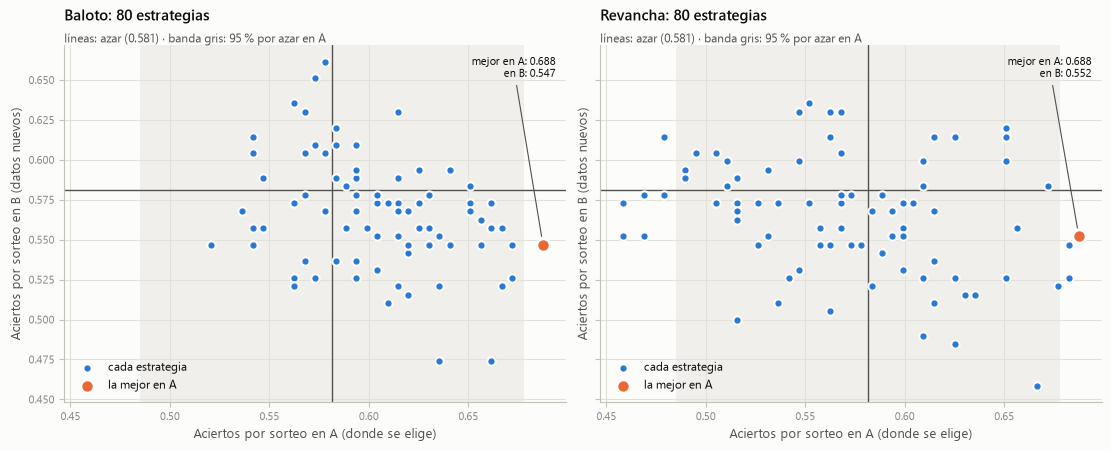

,mejor en A,aciertos en A,aciertos en B,banda 95 % por azar,promedio de las 80 en B,correlación A-B
juego,,,,,,
baloto,calientes_80,0.688,0.547,"[0.485, 0.678]",0.567,-0.329
revancha,calientes_60,0.688,0.552,"[0.485, 0.678]",0.564,-0.279


In [5]:
demos = {j: selection_bias_demo(data[j]) for j in JUEGOS}
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True, sharey=True, layout="constrained")
for ax, j in zip(axes, JUEGOS):
    d = demos[j]
    a = np.array([r["aciertos_A"] for r in d["estrategias"]])
    b = np.array([r["aciertos_B"] for r in d["estrategias"]])
    viz.selection_scatter(
        ax, a, b, int(np.argmax(a)), d["banda95_azar"]["A"], EXPECTED_HITS, f"{j.capitalize()}: 80 estrategias"
    )
viz.save(fig, FIG / "trampa_seleccion.png")
plt.show()

filas_sel = []
for j in JUEGOS:
    d = demos[j]
    a = np.array([r["aciertos_A"] for r in d["estrategias"]])
    b = np.array([r["aciertos_B"] for r in d["estrategias"]])
    best = d["mejor_en_A"]
    filas_sel.append(
        {
            "juego": j,
            "mejor en A": best["estrategia"],
            "aciertos en A": best["aciertos_A"],
            "aciertos en B": best["aciertos_B"],
            "banda 95 % por azar": ic(d["banda95_azar"]["A"]),
            "promedio de las 80 en B": b.mean(),
            "correlación A-B": np.corrcoef(a, b)[0, 1],
        }
    )
pd.DataFrame(filas_sel).set_index("juego")

In [6]:
b0 = filas_sel[0]
display(Markdown(f"""**Lectura.** En Baloto la mejor estrategia en A (*{b0['mejor en A']}*) logra {b0['aciertos en A']:.3f} aciertos por sorteo, en el borde o por encima de la banda del azar: parece un sistema ganador. En B, con datos que no vio, cae a {b0['aciertos en B']:.3f}. La correlación entre el rendimiento en A y en B de las 80 estrategias es {b0['correlación A-B']:+.2f}: **el pasado de una estrategia no dice nada de su futuro**.

Es exactamente lo que pasa al ajustar hiperparámetros mirando el conjunto de prueba, o al probar features "hasta que algo funcione": con suficientes intentos, siempre hay uno que sale bien por azar. La defensa es fijar las decisiones **antes** de mirar los resultados y medir en datos que no participaron en ninguna elección."""))

**Lectura.** En Baloto la mejor estrategia en A (*calientes_80*) logra 0.688 aciertos por sorteo, en el borde o por encima de la banda del azar: parece un sistema ganador. En B, con datos que no vio, cae a 0.547. La correlación entre el rendimiento en A y en B de las 80 estrategias es -0.33: **el pasado de una estrategia no dice nada de su futuro**.

Es exactamente lo que pasa al ajustar hiperparámetros mirando el conjunto de prueba, o al probar features "hasta que algo funcione": con suficientes intentos, siempre hay uno que sale bien por azar. La defensa es fijar las decisiones **antes** de mirar los resultados y medir en datos que no participaron en ninguna elección.

## Cómo se evita (lo que hace este proyecto)

| Riesgo | Defensa en este repo |
|---|---|
| Fuga en las features | Features calculadas con `past_counts` (solo sorteos anteriores) y un test que verifica que las de cada sorteo se obtienen sin conocerlo |
| Validación que mezcla pasado y futuro | Walk-forward con ventana creciente; el split aleatorio no existe fuera de este notebook |
| Buscar hasta encontrar | Hiperparámetros fijados de antemano; el modelo de producción (logística) se eligió a priori, no por métricas |
| Un método incapaz de ver señal | Control positivo: se verifica que los modelos detectan una señal plantada en datos sintéticos (notebook 03) |
| Maquillar resultados después | Registro de predicciones en vivo, append-only, guardado **antes** de cada sorteo |